# Understanding the Lag Plot

A lag plot is a scatter plot of a time series against a **lagged version of itself**: x-axis = y(t), y-axis = y(t+1). It tests whether successive observations are independent (random). If the data are truly random, the lag plot shows a structureless cloud; any visible pattern reveals autocorrelation — each point depends on the one before it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

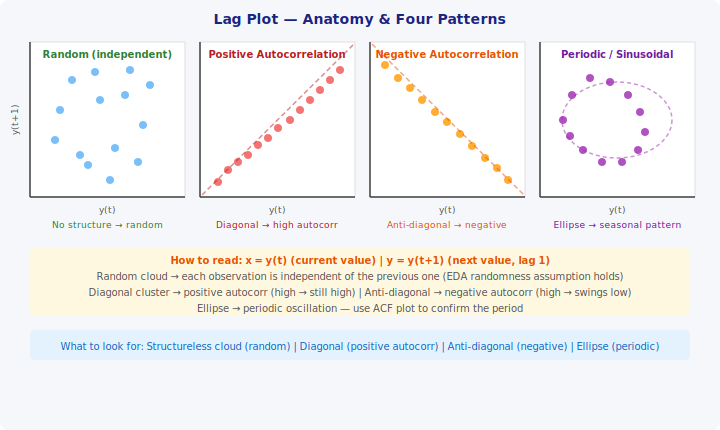

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="430"
     font-family="'Segoe UI', Arial, sans-serif">

  <rect width="720" height="430" fill="#F5F7FA" rx="8"/>
  <text x="360" y="24" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Lag Plot — Anatomy &amp; Four Patterns</text>

  <!-- ── PANEL 1: Random (structureless cloud) ── -->
  <rect x="30"  y="42" width="155" height="155" fill="white" stroke="#E0E0E0"/>
  <text x="107" y="58" text-anchor="middle" font-size="10" font-weight="bold" fill="#2E7D32">Random (independent)</text>
  <!-- scattered points -->
  <circle cx="55"  cy="140" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="72"  cy="80"  r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="88"  cy="165" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="100" cy="100" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="115" cy="148" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="130" cy="70"  r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="143" cy="125" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="60"  cy="110" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="80"  cy="155" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="95"  cy="72"  r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="110" cy="180" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="125" cy="95"  r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="138" cy="162" r="4" fill="#42A5F5" opacity="0.7"/>
  <circle cx="150" cy="85"  r="4" fill="#42A5F5" opacity="0.7"/>
  <!-- axes -->
  <line x1="30" y1="197" x2="185" y2="197" stroke="#424242" stroke-width="1.5"/>
  <line x1="30" y1="197" x2="30"  y2="42"  stroke="#424242" stroke-width="1.5"/>
  <text x="107" y="213" text-anchor="middle" font-size="9" fill="#555">y(t)</text>
  <text x="18"  y="120" text-anchor="middle" font-size="9" fill="#555"
        transform="rotate(-90 18 120)">y(t+1)</text>
  <text x="107" y="228" text-anchor="middle" font-size="9" fill="#2E7D32">No structure → random</text>

  <!-- ── PANEL 2: Positive autocorrelation (diagonal cluster) ── -->
  <rect x="200" y="42" width="155" height="155" fill="white" stroke="#E0E0E0"/>
  <text x="277" y="58" text-anchor="middle" font-size="10" font-weight="bold" fill="#B71C1C">Positive Autocorrelation</text>
  <!-- diagonal cluster top-left to bottom-right -->
  <circle cx="218" cy="182" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="228" cy="170" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="238" cy="162" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="248" cy="155" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="258" cy="145" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="268" cy="138" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="278" cy="128" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="290" cy="120" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="300" cy="110" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="310" cy="100" r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="320" cy="90"  r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="330" cy="80"  r="4" fill="#EF5350" opacity="0.8"/>
  <circle cx="340" cy="70"  r="4" fill="#EF5350" opacity="0.8"/>
  <!-- diagonal reference line -->
  <line x1="202" y1="195" x2="354" y2="44" stroke="#B71C1C" stroke-width="1.5" stroke-dasharray="5,3" opacity="0.5"/>
  <!-- axes -->
  <line x1="200" y1="197" x2="355" y2="197" stroke="#424242" stroke-width="1.5"/>
  <line x1="200" y1="197" x2="200" y2="42"  stroke="#424242" stroke-width="1.5"/>
  <text x="277" y="213" text-anchor="middle" font-size="9" fill="#555">y(t)</text>
  <text x="277" y="228" text-anchor="middle" font-size="9" fill="#B71C1C">Diagonal → high autocorr</text>

  <!-- ── PANEL 3: Negative autocorrelation (anti-diagonal) ── -->
  <rect x="370" y="42" width="155" height="155" fill="white" stroke="#E0E0E0"/>
  <text x="447" y="58" text-anchor="middle" font-size="10" font-weight="bold" fill="#E65100">Negative Autocorrelation</text>
  <!-- anti-diagonal cluster -->
  <circle cx="385" cy="65"  r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="398" cy="78"  r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="410" cy="88"  r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="422" cy="100" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="435" cy="112" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="447" cy="122" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="460" cy="134" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="472" cy="146" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="485" cy="158" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="497" cy="168" r="4" fill="#FF9800" opacity="0.8"/>
  <circle cx="508" cy="180" r="4" fill="#FF9800" opacity="0.8"/>
  <!-- anti-diagonal reference -->
  <line x1="372" y1="44" x2="524" y2="195" stroke="#E65100" stroke-width="1.5" stroke-dasharray="5,3" opacity="0.5"/>
  <!-- axes -->
  <line x1="370" y1="197" x2="525" y2="197" stroke="#424242" stroke-width="1.5"/>
  <line x1="370" y1="197" x2="370" y2="42"  stroke="#424242" stroke-width="1.5"/>
  <text x="447" y="213" text-anchor="middle" font-size="9" fill="#555">y(t)</text>
  <text x="447" y="228" text-anchor="middle" font-size="9" fill="#E65100">Anti-diagonal → negative</text>

  <!-- ── PANEL 4: Sinusoidal / periodic (ellipse) ── -->
  <rect x="540" y="42" width="155" height="155" fill="white" stroke="#E0E0E0"/>
  <text x="617" y="58" text-anchor="middle" font-size="10" font-weight="bold" fill="#6A1B9A">Periodic / Sinusoidal</text>
  <!-- ellipse cluster -->
  <ellipse cx="617" cy="120" rx="55" ry="38" fill="none" stroke="#CE93D8" stroke-width="1.5" stroke-dasharray="4,3"/>
  <circle cx="563" cy="120" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="572" cy="95"  r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="590" cy="78"  r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="610" cy="82"  r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="628" cy="95"  r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="640" cy="112" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="645" cy="132" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="638" cy="150" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="622" cy="162" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="602" cy="162" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="583" cy="150" r="4" fill="#9C27B0" opacity="0.8"/>
  <circle cx="570" cy="136" r="4" fill="#9C27B0" opacity="0.8"/>
  <!-- axes -->
  <line x1="540" y1="197" x2="695" y2="197" stroke="#424242" stroke-width="1.5"/>
  <line x1="540" y1="197" x2="540" y2="42"  stroke="#424242" stroke-width="1.5"/>
  <text x="617" y="213" text-anchor="middle" font-size="9" fill="#555">y(t)</text>
  <text x="617" y="228" text-anchor="middle" font-size="9" fill="#6A1B9A">Ellipse → seasonal pattern</text>

  <!-- ── BIG ANNOTATION LABELS ── -->
  <!-- how to read -->
  <rect x="30" y="248" width="660" height="68" fill="#FFF8E1" rx="4"/>
  <text x="360" y="264" text-anchor="middle" font-size="10" font-weight="bold" fill="#E65100">How to read: x = y(t)  (current value)   |   y = y(t+1)  (next value, lag 1)</text>
  <text x="360" y="280" text-anchor="middle" font-size="10" fill="#555">Random cloud → each observation is independent of the previous one (EDA randomness assumption holds)</text>
  <text x="360" y="296" text-anchor="middle" font-size="10" fill="#555">Diagonal cluster → positive autocorr (high → still high)   |   Anti-diagonal → negative autocorr (high → swings low)</text>
  <text x="360" y="312" text-anchor="middle" font-size="10" fill="#555">Ellipse → periodic oscillation — use ACF plot to confirm the period</text>

  <!-- takeaway -->
  <rect x="30" y="330" width="660" height="30" fill="#E3F2FD" rx="4"/>
  <text x="360" y="350" text-anchor="middle" font-size="10" fill="#1565C0">
    What to look for:  Structureless cloud (random)  |  Diagonal (positive autocorr)  |  Anti-diagonal (negative)  |  Ellipse (periodic)
  </text>
</svg>
"""
display(SVG(_svg))

## Interpreting a Lag Plot

| Pattern | Autocorrelation | What it means |
|---|---|---|
| **Structureless cloud** | None | Observations are independent — randomness assumption holds |
| **Diagonal cluster (↗)** | Positive | High values follow high values — persistent trend |
| **Anti-diagonal cluster (↘)** | Negative | High values followed by low values — oscillation |
| **Ellipse** | Periodic | Sinusoidal / seasonal pattern |
| **Multiple clusters** | Non-linear | Complex structure — investigate further |

**Lag k plot**: you can extend this to lag-2, lag-3, etc. (plot y(t) vs y(t+k)). The lag at which structure disappears reveals the effective autocorrelation range.

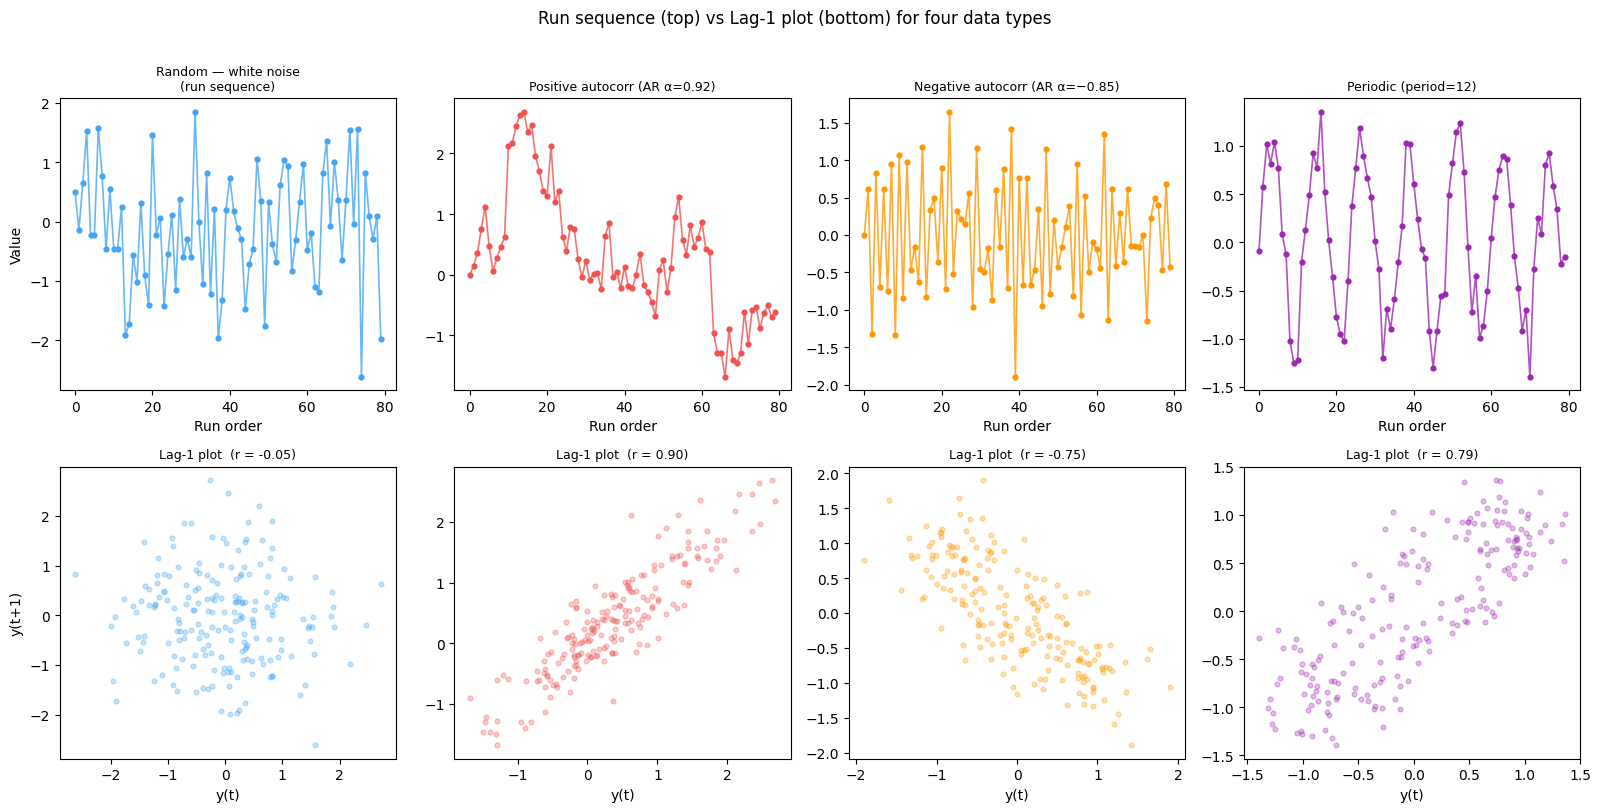

In [3]:
np.random.seed(42)
n = 200

random_data  = np.random.normal(0, 1, n)
pos_autocorr = np.zeros(n)
pos_autocorr[0] = 0
for i in range(1, n):
    pos_autocorr[i] = 0.92 * pos_autocorr[i-1] + np.random.normal(0, 0.4)

neg_autocorr = np.zeros(n)
neg_autocorr[0] = 0
for i in range(1, n):
    neg_autocorr[i] = -0.85 * neg_autocorr[i-1] + np.random.normal(0, 0.5)

periodic = np.sin(2 * np.pi * np.arange(n) / 12) + np.random.normal(0, 0.2, n)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

datasets = [
    (random_data,  'Random — white noise', '#42A5F5'),
    (pos_autocorr, 'Positive autocorr (AR α=0.92)', '#EF5350'),
    (neg_autocorr, 'Negative autocorr (AR α=−0.85)', '#FF9800'),
    (periodic,     'Periodic (period=12)', '#9C27B0'),
]

for col, (data, title, color) in enumerate(datasets):
    # Run sequence
    axes[0, col].plot(data[:80], color=color, linewidth=1.2, alpha=0.8)
    axes[0, col].scatter(range(80), data[:80], s=12, color=color, zorder=3)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].set_xlabel('Run order')
    if col == 0:
        axes[0, col].set_ylabel('Value')

    # Lag plot
    axes[1, col].scatter(data[:-1], data[1:], alpha=0.3, s=12, color=color)
    r = np.corrcoef(data[:-1], data[1:])[0, 1]
    axes[1, col].set_title(f'Lag-1 plot  (r = {r:.2f})', fontsize=9)
    axes[1, col].set_xlabel('y(t)')
    if col == 0:
        axes[1, col].set_ylabel('y(t+1)')

axes[0, 0].set_title('Random — white noise\n(run sequence)', fontsize=9)
plt.suptitle('Run sequence (top) vs Lag-1 plot (bottom) for four data types', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Best for** | Testing the randomness / independence assumption before modeling |
| **Axes** | x = y(t), y = y(t+1) — each point is a consecutive pair |
| **Cloud** | Random — no autocorrelation, EDA assumption satisfied |
| **Diagonal** | Positive autocorrelation — use AR/ARIMA model |
| **Anti-diagonal** | Negative autocorrelation — alternating high-low |
| **Ellipse** | Periodic — use ACF to find the period |
| **Pairs with** | Run sequence plot + ACF plot for complete time-series diagnosis |